# Resampling methods
Resampling methods are used to resample data from a fixed dataset and refit models to obtain additional information about the model like robustness or variance and resampling helps in model selection. 


# Cross Validation
In order to estimate the quality of a model which is fitted on a predictor X to a response y we use cross validation. This means we split the full dataset into two subsets the train set and the test set. The train set tends to contain 70-90% of all data and the test set the remaining data points. Then after fitting the model on the train set the model fitness or quality is assessed on the train set.

# The Validation set approach

In this approach one split between test and train set is made and randomly 70 - 90% of the available data points are used to train the model and the remaining data points are used as a validation or hold out set to assess the model quality using e.g. the MSE or the MAE.

## Example

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load data
auto_data = pd.read_csv(
    'data/Auto.data',
    delim_whitespace=True,
    header=None,
    na_values='?'
)

auto_data.columns = [
    'mpg', 'cylinders', 'displacement', 'horsepower',
    'weight', 'acceleration', 'model_year', 'origin', 'name'
]
# drop the 0 index column if exists
if 0 in auto_data.index:
    auto_data = auto_data.drop(index=0)

# Drop rows with missing horsepower
auto_data = auto_data.dropna(subset=['horsepower'])

# Response and predictor
Y = auto_data['mpg'].astype(float).values
hp = auto_data['horsepower'].astype(float).values

# Design matrix: intercept, hp, hp^2
X_design = np.column_stack([
    np.ones(len(hp)),
    hp,
    hp**2
])

# Fit on full data
beta_hat = np.linalg.lstsq(X_design, Y, rcond=None)[0]
print("Estimated coefficients (intercept, hp, hp^2):", beta_hat)

# -------------------------------------------------
# Repeated train/test splits
# -------------------------------------------------
for i in range(10):
    X_train, X_test, Y_train, Y_test = train_test_split(
        X_design, Y, test_size=0.1, random_state=i
    )
    
    beta_hat_train = np.linalg.lstsq(X_train, Y_train, rcond=None)[0]
    Y_pred = X_test @ beta_hat_train
    mse = np.mean((Y_test - Y_pred)**2)
    
    print(f"Split {i+1}: Test MSE = {mse:.3f}")


Estimated coefficients (intercept, hp, hp^2): [ 5.69000997e+01 -4.66189630e-01  1.23053610e-03]
Split 1: Test MSE = 15.977
Split 2: Test MSE = 17.265
Split 3: Test MSE = 23.743
Split 4: Test MSE = 16.834
Split 5: Test MSE = 13.476
Split 6: Test MSE = 24.597
Split 7: Test MSE = 17.410
Split 8: Test MSE = 16.456
Split 9: Test MSE = 12.453
Split 10: Test MSE = 15.962


C:\Users\Johannes\AppData\Local\Temp\ipykernel_14420\2246729714.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto_data = pd.read_csv(


## Leave one out cross validation (LOOCV)
This form of cross validation is closely realted to the idea of test and train split or validation set and train set but instead of randomly test a model on a subset of train and test data we train the model on all but one sample and repeat this n times where n is the size of the dataset. n models are fitted and the mse errors are calculated and finally the mean mse and the variance of the mse can be used as description of the model fitness. LOOCV is expensive to implement as it requires quite a lot of model fittings. One example were LOOCV is used is the area of human activity recognition were a model which predicts a categorical variable like running, walking, or dancing. Models are trained on all but one person in the train dataset and then the overall model performance is predicted across population.

# K fold cross validation
A closely to LOOCV related validation scheme is K fold cross validation were K is the number of splits in which the dataset is splitted. If we select K=n then we obtain the LOOCV. The cross validation estimate is then the average MSE over the K splits. The advantage of K fold cross valdiation over LOOCV is the lower computational effort as well as the better representation of the test error. This is due to the bias variance tradeoff as the LOOCV uses always all but 1 sample for each prediction which minimizes the bias while the variance is not well covered due to the small sample size in the test set per itteration. The LOOCV gives more flexibility compared to the K fold cross validation.

C:\Users\Johannes\AppData\Local\Temp\ipykernel_14420\2241024890.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  auto_data = pd.read_csv(


LOOCV MSE for degrees 1 to 20: [np.float64(24.231513517929216), np.float64(19.248213124490103), np.float64(19.334984063996654), np.float64(19.424430313928784), np.float64(18.87352836522997), np.float64(20.710187833523396), np.float64(34.48989485210374), np.float64(72.12052689867788), np.float64(132.1076491279386), np.float64(202.44372308328823), np.float64(280.0218577384233), np.float64(368.0477996693463), np.float64(535.7564476532474), np.float64(552.3349624124621), np.float64(565.1357127666313), np.float64(576.6964942101131), np.float64(588.3900492145522), np.float64(600.9711085801614), np.float64(614.8418923406576), np.float64(630.2179565540324)]
k-Fold CV MSE for degrees 1 to 20: [np.float64(24.18807581355331), np.float64(19.222140043392166), np.float64(19.260363581801048), np.float64(19.343933356246282), np.float64(18.887950129115524), np.float64(20.713828527367912), np.float64(34.248130391946106), np.float64(70.93243630982954), np.float64(129.65015351176422), np.float64(198.77456

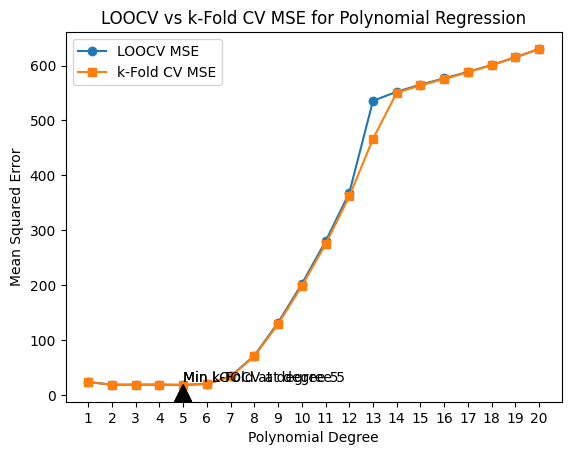

In [37]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
# LOOCV and k-Fold CV can be implemented similarly by iterating over data splits

# Use the Auto dataset again and implement LOOCV and k-Fold CV to estimate test MSE for polynomial regression models of degrees 1 to 20.

# load data

auto_data = pd.read_csv(
    'data/Auto.data',
    delim_whitespace=True,
    header=None,
    na_values='?'
)
auto_data.columns = [
    'mpg', 'cylinders', 'displacement', 'horsepower',
    'weight', 'acceleration', 'model_year', 'origin', 'name'
]   
# drop the 0 index column if exists
if 0 in auto_data.index:
    auto_data = auto_data.drop(index=0)
# Drop rows with missing horsepower
auto_data = auto_data.dropna(subset=['horsepower'])
Y = auto_data['mpg'].astype(float).values
hp = auto_data['horsepower'].astype(float).values
n = len(Y)
max_degree = 20
# LOOCV
loocv_mse = []
for degree in range(1, max_degree + 1):
    sq_errors = []
    for i in range(n):
        X_loo = np.column_stack([hp**d for d in range(degree + 1)])
        X_train = np.delete(X_loo, i, axis=0)
        Y_train = np.delete(Y, i)
        X_val = X_loo[i, :].reshape(1, -1)
        Y_val = Y[i]
        
        beta_hat_loo = np.linalg.lstsq(X_train, Y_train, rcond=None)[0]
        Y_pred_loo = X_val @ beta_hat_loo
        sq_errors.append((Y_val - Y_pred_loo[0])**2)
    
    loocv_mse.append(np.mean(sq_errors))
print("LOOCV MSE for degrees 1 to 20:", loocv_mse)
# k-Fold CV

k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)
kfold_mse = []
for degree in range(1, max_degree + 1):
    sq_errors = []
    X_kfold = np.column_stack([hp**d for d in range(degree + 1)])
    
    for train_index, val_index in kf.split(X_kfold):
        X_train, X_val = X_kfold[train_index], X_kfold[val_index]
        Y_train, Y_val = Y[train_index], Y[val_index]
        
        beta_hat_kfold = np.linalg.lstsq(X_train, Y_train, rcond=None)[0]
        Y_pred_kfold = X_val @ beta_hat_kfold
        sq_errors.extend((Y_val - Y_pred_kfold)**2)
    
    kfold_mse.append(np.mean(sq_errors))
print("k-Fold CV MSE for degrees 1 to 20:", kfold_mse)

# plot the MSE curves of LOOCV and k-Fold CV against polynomial degrees and annotate the degree that minimizes each curve.


degrees = np.arange(1, max_degree + 1)
plt.plot(degrees, loocv_mse, label='LOOCV MSE', marker='o')
plt.plot(degrees, kfold_mse, label='k-Fold CV MSE', marker='s')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('LOOCV vs k-Fold CV MSE for Polynomial Regression')
plt.xticks(degrees)
plt.legend()
# Annotate minimum points
min_loocv_degree = np.argmin(loocv_mse) + 1
min_kfold_degree = np.argmin(kfold_mse) + 1
plt.annotate(f'Min LOOCV at degree {min_loocv_degree}',
             xy=(min_loocv_degree, loocv_mse[min_loocv_degree - 1]),
             xytext=(min_loocv_degree, loocv_mse[min_loocv_degree - 1] + 5),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.annotate(f'Min k-Fold at degree {min_kfold_degree}',
                xy=(min_kfold_degree, kfold_mse[min_kfold_degree - 1]),
                xytext=(min_kfold_degree, kfold_mse[min_kfold_degree - 1] + 5),
                arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

# Bootstrapping
Bootstrapping treats the observed dataset as if it were the population. By repeatedly sampling with replacement, we mimic the process of drawing new datasets from the true data-generating mechanism. In contrast to cross validation approaches we do not split the data in train and test sets where we remove parts of the data before training the model but instead we resample the datasets with replacement to generate Bootstraps $B$ of the datasets. Then we train our model on the bootstraps and can then estimate the variance and the standard error of the predictor.

### Bootstrap variance of regression coefficients

In the regression setting, we denote the model parameters by  
$\beta = (\beta_0, \beta_1, \dots, \beta_p)$.

The bootstrap approximation of the variance of a coefficient $\hat{\beta}_j$ is

$$
\mathrm{Var}(\hat{\beta}_j)
\;\approx\;
\frac{1}{B-1}
\sum_{b=1}^{B}
\left(
\hat{\beta}_j^{(b)} - \bar{\hat{\beta}}_j
\right)^2
$$

where

- $B$ is the number of bootstrap samples.
- $\hat{\beta}_j^{(b)}$ is the estimate of coefficient $j$ obtained from the
  $b$-th bootstrap sample (sampling with replacement from the original data).
- $\bar{\hat{\beta}}_j$ is the mean of the bootstrap estimates,

$$
\bar{\hat{\beta}}_j = \frac{1}{B} \sum_{b=1}^{B} \hat{\beta}_j^{(b)} .
$$

This formula is simply the **sample variance** of the bootstrap estimates
$\{\hat{\beta}_j^{(1)}, \dots, \hat{\beta}_j^{(B)}\}$.

#### Interpretation

- The true sampling distribution of $\hat{\beta}_j$ is unknown.
- Bootstrap replaces it by the empirical distribution obtained from resampling
  the observed data.
- The spread of the bootstrap estimates measures how sensitive
  $\hat{\beta}_j$ is to small changes in the data.

A large bootstrap variance indicates an unstable coefficient (high variance),
while a small bootstrap variance indicates a stable estimate.

The corresponding bootstrap standard error is

$$
\mathrm{SE}_{\text{boot}}(\hat{\beta}_j)
=
\sqrt{\mathrm{Var}(\hat{\beta}_j)} .
$$

This approach avoids analytical variance calculations and applies to a wide
range of models, including linear regression, logistic regression, and other
generalized linear models.



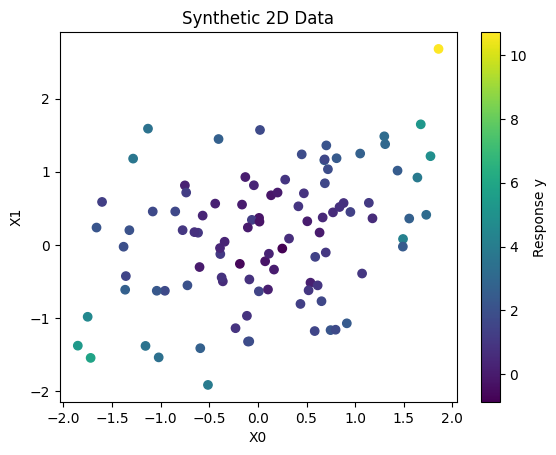

True standard errors of coefficients (intercept, X0, X1): [0.24300495 0.38973332 0.3859612 ]
Bootstrap estimated standard errors of coefficients (intercept, X0, X1): [0.16417495 0.22959727 0.15664866]


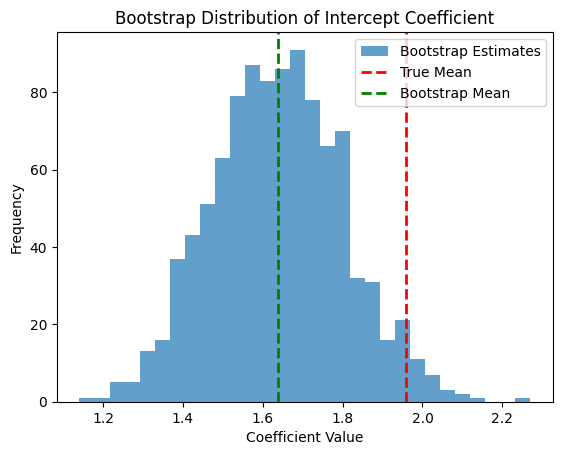

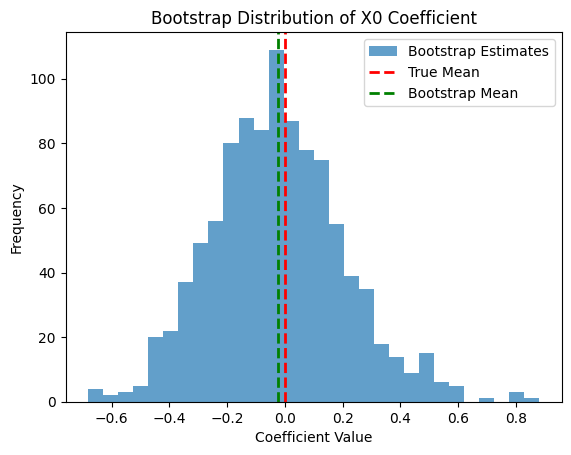

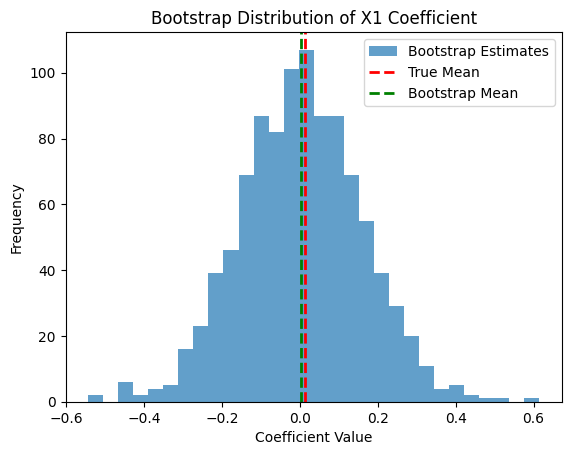

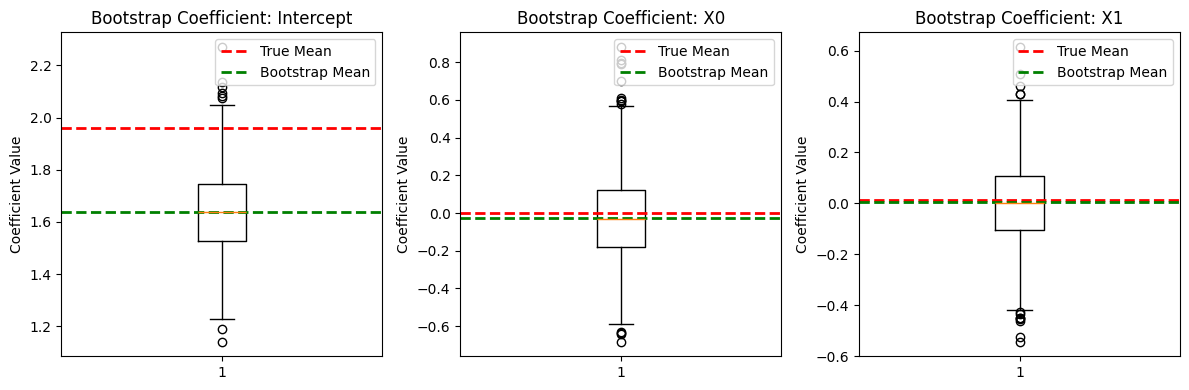

In [38]:
# Bootstrap example
# lets generate a synthetic dataset for demonstration
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
# 2D Gaussian data
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]
data = np.random.multivariate_normal(mean, cov, size=100)
X0 = data[:, 0]
X1 = data[:, 1]

y = X0**2 + X1**2 + np.random.normal(0, 0.5, size=X0.shape)

# scatter plot of the data
plt.scatter(X0, X1, c=y, cmap='viridis')
plt.colorbar(label='Response y')
plt.xlabel('X0')
plt.ylabel('X1')
plt.title('Synthetic 2D Data')
plt.show()

# now we can estimate the true standard error of the coefficients using a monte carlo simulation
n_simulations = 1000
true_betas = []
for _ in range(n_simulations):
    # neue daten generieren --> geht nur weil wir die wahre verteilung kennen (Nur in einer Simulation)
    data = np.random.multivariate_normal(mean, cov, size=100)
    X0 = data[:, 0]
    X1 = data[:, 1]
    y_sim = X0**2 + X1**2 + np.random.normal(0, 0.5, size=X0.shape) # new response with noise
    X_design = np.column_stack([np.ones(len(X0)), X0, X1])
    # fit model
    beta_hat = np.linalg.lstsq(X_design, y_sim, rcond=None)[0]
    # store coefficients
    true_betas.append(beta_hat)
    
true_betas = np.array(true_betas)
true_se = np.std(true_betas, axis=0)
mean_betas = np.mean(true_betas, axis=0)
print("True standard errors of coefficients (intercept, X0, X1):", true_se)

# jetzt ueber bootstrap die standardfehler schaetzen
n_bootstraps = 1000
X_design = np.column_stack([np.ones(len(X0)), X0, X1])
bootstrap_betas = []
for _ in range(n_bootstraps):
    # bootstrap sampling with replacement from real datatset
    indices = np.random.choice(len(y), size=len(y), replace=True)
    X_boot = X_design[indices]
    y_boot = y[indices]
    # fit model
    beta_hat_boot = np.linalg.lstsq(X_boot, y_boot, rcond=None)[0]
    # store coefficients
    bootstrap_betas.append(beta_hat_boot)
bootstrap_betas = np.array(bootstrap_betas)
bootstrap_se = np.std(bootstrap_betas, axis=0)
print("Bootstrap estimated standard errors of coefficients (intercept, X0, X1):", bootstrap_se)
bootstrap_mean_betas = np.mean(bootstrap_betas, axis=0)

# compare true and bootstrap estimates using a histogram plot
coeff_names = ['Intercept', 'X0', 'X1']
for i in range(3):
    plt.figure()
    plt.hist(bootstrap_betas[:, i], bins=30, alpha=0.7, label='Bootstrap Estimates')
    plt.axvline(mean_betas[i], color='red', linestyle='dashed', linewidth=2, label='True Mean')
    plt.axvline(bootstrap_mean_betas[i], color='green', linestyle='dashed', linewidth=2, label='Bootstrap Mean')
    plt.title(f'Bootstrap Distribution of {coeff_names[i]} Coefficient')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    
# now as boxplot in 3 subplots
plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.boxplot(bootstrap_betas[:, i], vert=True)
    plt.axhline(mean_betas[i], color='red', linestyle='dashed', linewidth=2, label='True Mean')
    plt.axhline(bootstrap_mean_betas[i], color='green', linestyle='dashed', linewidth=2, label='Bootstrap Mean')
    plt.title(f'Bootstrap Coefficient: {coeff_names[i]}')
    plt.ylabel('Coefficient Value')
    plt.legend()
plt.tight_layout()

    

Although the linear regression model is fitted correctly from a numerical point of view, it is statistically misspecified. The true data-generating process contains quadratic terms, while the fitted model only includes linear predictors. As a consequence, the intercept absorbs most of the systematic structure that cannot be represented by the model. This leads to biased coefficient estimates and explains why bootstrap-based standard errors differ from the Monte Carlo standard errors obtained under the true data-generating process.

Monte Carlo true SE (Intercept, X0^2, X1^2): [0.0701088  0.03862839 0.04019539]
Monte Carlo mean coefficients: [5.74892095e-04 1.00059110e+00 9.98793364e-01]
Estimated coefficients (Intercept, X0^2, X1^2): [-0.02182468  1.06256425  0.91820627]
Bootstrap SE (Intercept, X0^2, X1^2): [0.07060731 0.06150986 0.0445091 ]
Bootstrap mean coefficients: [-0.02669639  1.06529441  0.92380769]


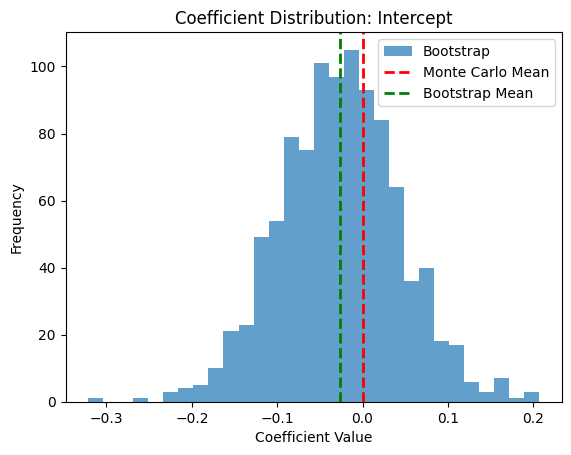

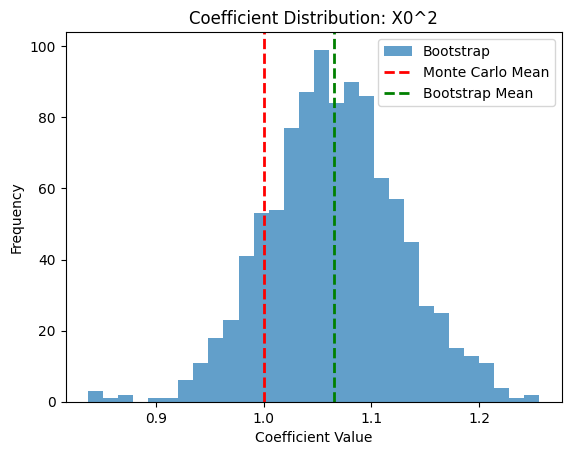

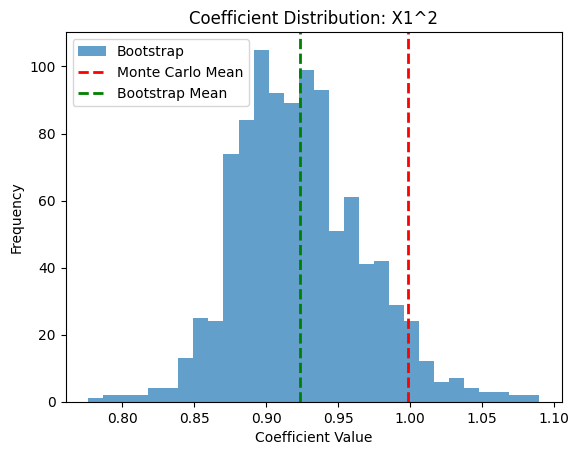

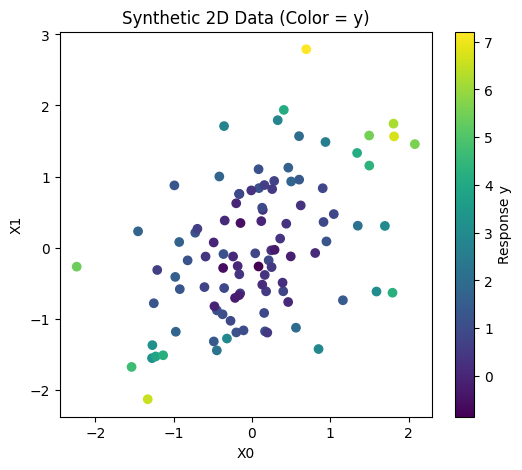

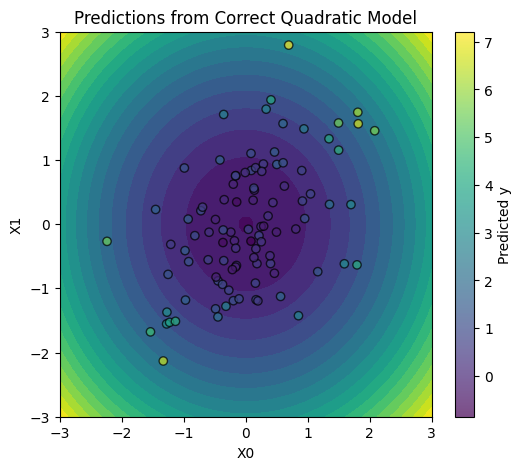

In [41]:
# Bootstrap + Monte Carlo Example with Correct Model
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate synthetic 2D data
mean = [0, 0]
cov = [[1, 0.5], [0.5, 1]]
n_samples = 100

# Number of simulations/bootstraps
n_simulations = 1000
n_bootstraps = 1000

# Function to generate data
def generate_data(n_samples):
    data = np.random.multivariate_normal(mean, cov, size=n_samples)
    X0 = data[:, 0]
    X1 = data[:, 1]
    y = X0**2 + X1**2 + np.random.normal(0, 0.5, size=n_samples)
    return X0, X1, y

# --- Monte Carlo to estimate true standard errors ---
true_betas = []
for _ in range(n_simulations):
    X0, X1, y = generate_data(n_samples)
    X_design = np.column_stack([np.ones(n_samples), X0**2, X1**2])
    beta_hat = np.linalg.lstsq(X_design, y, rcond=None)[0]
    true_betas.append(beta_hat)
true_betas = np.array(true_betas)
true_se = np.std(true_betas, axis=0)
mean_betas = np.mean(true_betas, axis=0)
print("Monte Carlo true SE (Intercept, X0^2, X1^2):", true_se)
print("Monte Carlo mean coefficients:", mean_betas)

# --- Generate a single dataset for bootstrap ---
X0, X1, y = generate_data(n_samples)
X_design = np.column_stack([np.ones(n_samples), X0**2, X1**2])

# Fit model on original dataset
beta_hat = np.linalg.lstsq(X_design, y, rcond=None)[0]
print("Estimated coefficients (Intercept, X0^2, X1^2):", beta_hat)

# --- Bootstrap ---
bootstrap_betas = []
for _ in range(n_bootstraps):
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    X_boot = X_design[indices]
    y_boot = y[indices]
    beta_hat_boot = np.linalg.lstsq(X_boot, y_boot, rcond=None)[0]
    bootstrap_betas.append(beta_hat_boot)
bootstrap_betas = np.array(bootstrap_betas)
bootstrap_se = np.std(bootstrap_betas, axis=0)
bootstrap_mean_betas = np.mean(bootstrap_betas, axis=0)
print("Bootstrap SE (Intercept, X0^2, X1^2):", bootstrap_se)
print("Bootstrap mean coefficients:", bootstrap_mean_betas)

# --- Compare distributions with histograms ---
coeff_names = ['Intercept', 'X0^2', 'X1^2']
for i in range(3):
    plt.figure()
    plt.hist(bootstrap_betas[:, i], bins=30, alpha=0.7, label='Bootstrap')
    plt.axvline(mean_betas[i], color='red', linestyle='dashed', linewidth=2, label='Monte Carlo Mean')
    plt.axvline(bootstrap_mean_betas[i], color='green', linestyle='dashed', linewidth=2, label='Bootstrap Mean')
    plt.title(f'Coefficient Distribution: {coeff_names[i]}')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

# --- Scatter plot of synthetic data ---
plt.figure(figsize=(6,5))
plt.scatter(X0, X1, c=y, cmap='viridis')
plt.colorbar(label='Response y')
plt.xlabel('X0')
plt.ylabel('X1')
plt.title('Synthetic 2D Data (Color = y)')
plt.show()

# --- Optional: compare predictions ---
x0_grid, x1_grid = np.meshgrid(np.linspace(-3, 3, 50), np.linspace(-3, 3, 50))
X_grid_design = np.column_stack([np.ones(x0_grid.size), x0_grid.ravel()**2, x1_grid.ravel()**2])
y_pred = X_grid_design @ beta_hat
y_pred_grid = y_pred.reshape(x0_grid.shape)

plt.figure(figsize=(6,5))
plt.contourf(x0_grid, x1_grid, y_pred_grid, cmap='viridis', levels=20)
plt.scatter(X0, X1, c=y, edgecolor='k', alpha=0.7)
plt.colorbar(label='Predicted y')
plt.xlabel('X0')
plt.ylabel('X1')
plt.title('Predictions from Correct Quadratic Model')
plt.show()
